### Finding out the Checkpoints to Download for Testing

In [ ]:
import pandas as pd
import numpy as np
import os
import re

DIR = r"C:\Users\Faruk\Code\CCIR_Project"
FIGURES_DIR = r"Figures"

LOO_SPLITS = {
    "LOO_BHRC": "BHRC",
    "LOO_CCNP": "CCNP",
    "LOO_HBN":  "HBN",
    "LOO_NKI":  "NKI",
    "LOO_PNC":  "PNC",
}

TOP_K = 5

In [2]:
def arch_group(row):
    """One of 6 canonical groups based on trial_id suffix + degree_norm."""
    m = re.search(r'_(gcn|gat)_(fmri|multi)$', row["trial_id"])
    if m is None:
        return "unknown"
    arch = m.group(1).upper()
    mod  = "fMRI&sMRI" if m.group(2) == "multi" else "fMRI"
    deg  = str(row["degree_norm"]).strip().lower() in ("true", "1")
    return f"{arch}_{mod}" + ("" if deg or arch == "GAT" else "_nodeg")


all_dfs = {}
for split, test_study in LOO_SPLITS.items():
    df = pd.read_csv(os.path.join(DIR, split, "results_table.csv"))
    df["arch_group"] = df.apply(arch_group, axis=1)
    all_dfs[split] = df
    print(f"{split}: {len(df)} trials")
    print(df["arch_group"].value_counts().to_string(), "\n")

LOO_BHRC: 2430 trials
arch_group
GAT_fMRI               729
GAT_fMRI&sMRI          729
GCN_fMRI               243
GCN_fMRI&sMRI          243
GCN_fMRI_nodeg         243
GCN_fMRI&sMRI_nodeg    243 

LOO_CCNP: 2430 trials
arch_group
GAT_fMRI&sMRI          729
GAT_fMRI               729
GCN_fMRI               243
GCN_fMRI&sMRI          243
GCN_fMRI_nodeg         243
GCN_fMRI&sMRI_nodeg    243 

LOO_HBN: 2430 trials
arch_group
GAT_fMRI&sMRI          729
GAT_fMRI               729
GCN_fMRI               243
GCN_fMRI&sMRI          243
GCN_fMRI_nodeg         243
GCN_fMRI&sMRI_nodeg    243 

LOO_NKI: 2430 trials
arch_group
GAT_fMRI               729
GAT_fMRI&sMRI          729
GCN_fMRI               243
GCN_fMRI_nodeg         243
GCN_fMRI&sMRI          243
GCN_fMRI&sMRI_nodeg    243 

LOO_PNC: 2429 trials
arch_group
GAT_fMRI               729
GAT_fMRI&sMRI          728
GCN_fMRI_nodeg         243
GCN_fMRI&sMRI          243
GCN_fMRI&sMRI_nodeg    243
GCN_fMRI               243 



In [3]:
GROUPS = [
    "GCN_fMRI",
    "GCN_fMRI_nodeg",
    "GCN_fMRI&sMRI",
    "GCN_fMRI&sMRI_nodeg",
    "GAT_fMRI",
    "GAT_fMRI&sMRI",
]

COLS = ["trial_id", "best_state_val_loss", "best_val_r", "best_val_mae", "fc_processing", "lr", "weight_decay"]

top_k = {}  # top_k[split][group] = DataFrame

for split, df in all_dfs.items():
    top_k[split] = {}
    for group in GROUPS:
        sub = (
            df[df["arch_group"] == group]
            .nsmallest(TOP_K, "best_state_val_loss")[COLS]
            .reset_index(drop=True)
        )
        top_k[split][group] = sub

# Display
for split, test_study in LOO_SPLITS.items():
    print(f"\n{'='*72}")
    print(f"  {split}  (test: {test_study})")
    print(f"{'='*72}")
    for group in GROUPS:
        sub = top_k[split][group]
        print(f"\n  [{group}]  (n={len(sub)})")
        print(sub.to_string(index=True))


  LOO_BHRC  (test: BHRC)

  [GCN_fMRI]  (n=5)
                        trial_id  best_state_val_loss  best_val_r  best_val_mae fc_processing     lr  weight_decay
0   trial_1.32.2.1.3.10_gcn_fmri             0.013856       0.743         2.054        per_10  0.010       0.00001
1   trial_1.32.2.3.2.10_gcn_fmri             0.014157       0.722         2.088        per_10  0.001       0.00100
2  trial_1.128.3.2.2.20_gcn_fmri             0.014170       0.719         2.086        per_20  0.001       0.00010
3   trial_1.64.2.2.2.50_gcn_fmri             0.014292       0.718         2.095        per_50  0.001       0.00010
4   trial_1.32.2.1.2.20_gcn_fmri             0.014312       0.715         2.094        per_20  0.001       0.00001

  [GCN_fMRI_nodeg]  (n=5)
                              trial_id  best_state_val_loss  best_val_r  best_val_mae fc_processing     lr  weight_decay
0   trial_1_nodeg.32.2.1.3.10_gcn_fmri             0.013243       0.746         2.018        per_10  0.010       0.

In [4]:
print("# ===== DOWNLOAD MANIFEST =====")
print(f"# Top-{TOP_K} per architecture per split  (ranked by best_state_val_loss ↑)")
print("# Files needed per trial: config.json  +  ckpt/best_model.pth\n")

all_trial_ids = []

for split, test_study in LOO_SPLITS.items():
    print(f"# --- {split} (test={test_study}) ---")
    for group in GROUPS:
        ids = top_k[split][group]["trial_id"].tolist()
        for tid in ids:
            loss = top_k[split][group].loc[top_k[split][group]["trial_id"] == tid, "best_state_val_loss"].values[0]
            print(f"{tid}  # {group}  val_loss={loss:.5f}")
            all_trial_ids.append(tid)
    print()

print(f"# Total: {len(all_trial_ids)} trials  ({len(set(all_trial_ids))} unique)")

# ===== DOWNLOAD MANIFEST =====
# Top-5 per architecture per split  (ranked by best_state_val_loss ↑)
# Files needed per trial: config.json  +  ckpt/best_model.pth

# --- LOO_BHRC (test=BHRC) ---
trial_1.32.2.1.3.10_gcn_fmri  # GCN_fMRI  val_loss=0.01386
trial_1.32.2.3.2.10_gcn_fmri  # GCN_fMRI  val_loss=0.01416
trial_1.128.3.2.2.20_gcn_fmri  # GCN_fMRI  val_loss=0.01417
trial_1.64.2.2.2.50_gcn_fmri  # GCN_fMRI  val_loss=0.01429
trial_1.32.2.1.2.20_gcn_fmri  # GCN_fMRI  val_loss=0.01431
trial_1_nodeg.32.2.1.3.10_gcn_fmri  # GCN_fMRI_nodeg  val_loss=0.01324
trial_1_nodeg.128.2.2.2.10_gcn_fmri  # GCN_fMRI_nodeg  val_loss=0.01353
trial_1_nodeg.32.3.1.2.50_gcn_fmri  # GCN_fMRI_nodeg  val_loss=0.01379
trial_1_nodeg.128.1.3.2.20_gcn_fmri  # GCN_fMRI_nodeg  val_loss=0.01398
trial_1_nodeg.128.1.2.2.10_gcn_fmri  # GCN_fMRI_nodeg  val_loss=0.01402
trial_2.8.2.1.3.20_gcn_multi  # GCN_fMRI&sMRI  val_loss=0.01146
trial_2.16.2.2.2.50_gcn_multi  # GCN_fMRI&sMRI  val_loss=0.01162
trial_2.64.3.1.3.20_g

### Load the test_results and merge with the top-k trials

In [5]:
def arch_group_test(row):
    """One of 6 canonical groups based on trial_id suffix + degree_norm."""
    m = re.search(r'_(gcn|gat)_(fmri|multi)$', row["trial_id"])
    if m is None:
        return "unknown"
    arch = m.group(1).upper()
    mod  = "fMRI&sMRI" if m.group(2) == "multi" else "fMRI"
    deg  = not any(el.startswith("nodeg") for el in row["trial_id"].split("_"))
    return f"{arch}_{mod}" + ("" if deg or arch == "GAT" else "_nodeg")


for split, test_study in LOO_SPLITS.items():
    test_res = pd.read_csv(f"{DIR}/LOO_{test_study}/test_results.csv")
    test_res["arch_group"] = test_res.apply(arch_group_test, axis=1)
    for group in GROUPS:
        test_res_temp = test_res[test_res["arch_group"] == group].copy()
        top_k[split][group] = (
            top_k[split][group]
            .merge(test_res_temp, on="trial_id", how="left")
            .drop(columns=["train_datasets", "test_datasets", "arch_group"], errors="ignore")
        )

### Tabulating the Results

In [6]:
print(GROUPS)

['GCN_fMRI', 'GCN_fMRI_nodeg', 'GCN_fMRI&sMRI', 'GCN_fMRI&sMRI_nodeg', 'GAT_fMRI', 'GAT_fMRI&sMRI']


In [7]:
from IPython.display import display


for split, test_study in LOO_SPLITS.items():
    print(split)
    display(top_k[split]["GCN_fMRI"].head())

LOO_BHRC


,trial_id,best_state_val_loss,best_val_r,best_val_mae,fc_processing,lr,weight_decay,test_r,test_r2,test_mae,test_mse
0,trial_1.32.2.1.3.10_gcn_fmri,0.013856,0.743,2.054,per_10,0.010,0.00001,0.3976,-0.5707,1.8530,4.9554
1,trial_1.32.2.3.2.10_gcn_fmri,0.014157,0.722,2.088,per_10,0.001,0.00100,0.3766,-3.9453,3.5683,15.6022
2,trial_1.128.3.2.2.20_gcn_fmri,0.014170,0.719,2.086,per_20,0.001,0.00010,0.3771,-1.8332,2.6198,8.9386
3,trial_1.64.2.2.2.50_gcn_fmri,0.014292,0.718,2.095,per_50,0.001,0.00010,0.4001,-1.1000,2.2151,6.6253
4,trial_1.32.2.1.2.20_gcn_fmri,0.014312,0.715,2.094,per_20,0.001,0.00001,0.1471,-1.7429,2.4933,8.6537


LOO_CCNP


,trial_id,best_state_val_loss,best_val_r,best_val_mae,fc_processing,lr,weight_decay,test_r,test_r2,test_mae,test_mse
0,trial_1.64.3.1.3.10_gcn_fmri,0.011378,0.806,1.874,per_10,0.010,0.00001,0.0854,-0.3073,2.9141,12.9582
1,trial_1.128.1.3.2.10_gcn_fmri,0.011739,0.797,1.903,per_10,0.001,0.00100,0.0276,-0.4238,3.0750,14.1125
2,trial_1.32.3.1.3.10_gcn_fmri,0.011989,0.790,1.913,per_10,0.010,0.00001,0.0341,-0.2586,2.8666,12.4754
3,trial_1.32.3.2.2.10_gcn_fmri,0.012026,0.790,1.924,per_10,0.001,0.00010,0.0663,-0.1942,2.8310,11.8375
4,trial_1.64.3.1.3.20_gcn_fmri,0.012551,0.779,2.011,per_20,0.010,0.00001,-0.0093,-0.3662,2.9956,13.5419


LOO_HBN


,trial_id,best_state_val_loss,best_val_r,best_val_mae,fc_processing,lr,weight_decay,test_r,test_r2,test_mae,test_mse
0,trial_1.64.3.1.2.20_gcn_fmri,0.014800,0.726,2.155,per_20,0.001,0.00001,0.6073,-0.0907,2.8185,13.4420
1,trial_1.32.3.2.3.10_gcn_fmri,0.015191,0.712,2.168,per_10,0.010,0.00010,0.6681,0.2668,2.3839,9.0363
2,trial_1.32.3.1.2.10_gcn_fmri,0.015411,0.708,2.168,per_10,0.001,0.00001,0.7235,0.4817,2.0143,6.3872
3,trial_1.128.1.3.2.20_gcn_fmri,0.015712,0.704,2.224,per_20,0.001,0.00100,0.5955,0.2923,2.4650,8.7224
4,trial_1.32.3.1.2.20_gcn_fmri,0.015810,0.699,2.212,per_20,0.001,0.00001,0.6785,0.4446,2.0834,6.8447


LOO_NKI


,trial_id,best_state_val_loss,best_val_r,best_val_mae,fc_processing,lr,weight_decay,test_r,test_r2,test_mae,test_mse
0,trial_1.128.3.1.3.10_gcn_fmri,0.014301,0.735,2.043,per_10,0.0100,0.00001,0.7618,-0.0511,2.9070,11.6025
1,trial_1.128.2.1.3.10_gcn_fmri,0.015131,0.735,2.124,per_10,0.0100,0.00001,0.7584,0.0480,2.6327,10.5093
2,trial_1.128.2.3.1.50_gcn_fmri,0.015151,0.711,2.152,per_50,0.0001,0.00100,0.7212,-1.5197,4.7391,27.8146
3,trial_1.64.3.2.2.10_gcn_fmri,0.015416,0.707,2.235,per_10,0.0010,0.00010,0.7844,0.5913,1.6647,4.5113
4,trial_1.128.3.2.2.50_gcn_fmri,0.015574,0.702,2.191,per_50,0.0010,0.00010,0.7683,0.5271,1.8715,5.2206


LOO_PNC


,trial_id,best_state_val_loss,best_val_r,best_val_mae,fc_processing,lr,weight_decay,test_r,test_r2,test_mae,test_mse
0,trial_1.32.3.1.2.20_gcn_fmri,0.009679,0.768,1.686,per_20,0.0010,0.00001,0.1828,-1.0767,4.1178,24.3450
1,trial_1.32.1.2.2.10_gcn_fmri,0.009735,0.770,1.701,per_10,0.0010,0.00010,0.3198,-2.7082,5.7933,43.4712
2,trial_1.128.3.2.1.50_gcn_fmri,0.009896,0.761,1.727,per_50,0.0001,0.00010,0.1604,-2.4190,5.4702,40.0810
3,trial_1.32.1.2.2.20_gcn_fmri,0.009900,0.761,1.735,per_20,0.0010,0.00010,0.1954,-1.6058,4.6813,30.5477
4,trial_1.32.3.1.2.10_gcn_fmri,0.009950,0.761,1.717,per_10,0.0010,0.00001,0.2810,-1.9840,5.0658,34.9810


In [8]:
DISPLAY_COLS = ["trial_id", "fc_processing", "lr", "weight_decay",
                "best_val_r", "best_val_mae", "test_r", "test_mae"]

def show_group(group):
    print(f"\n{'#'*72}")
    print(f"  {group}")
    print(f"{'#'*72}")
    for split, test_study in LOO_SPLITS.items():
        df = top_k[split][group].copy()
        print(f"\n  {split}  (test: {test_study})")
        cols = [c for c in DISPLAY_COLS if c in df.columns]
        display(df[cols].style.format({
            "lr":           "{:.0e}",
            "weight_decay": "{:.0e}",
            "best_val_r":   "{:.3f}",
            "best_val_mae": "{:.2f}",
            "test_r":       "{:.3f}",
            "test_mae":     "{:.2f}",
        }).hide(axis="index"))

        r_val    = df["best_val_r"].dropna()
        mae_val  = df["best_val_mae"].dropna()
        r_test   = df["test_r"].dropna()
        mae_test = df["test_mae"].dropna()
        if not r_test.empty:
            print(f"  Val   r: {r_val.mean():.3f} ± {r_val.std():.3f}   MAE: {mae_val.mean():.2f} ± {mae_val.std():.2f}")
            print(f"  Test  r: {r_test.mean():.3f} ± {r_test.std():.3f}   MAE: {mae_test.mean():.2f} ± {mae_test.std():.2f}  (n={len(r_test)})")

In [9]:
show_group("GCN_fMRI")


########################################################################
  GCN_fMRI
########################################################################

  LOO_BHRC  (test: BHRC)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_1.32.2.1.3.10_gcn_fmri,per_10,1e-02,1e-05,0.743,2.05,0.398,1.85
trial_1.32.2.3.2.10_gcn_fmri,per_10,1e-03,1e-03,0.722,2.09,0.377,3.57
trial_1.128.3.2.2.20_gcn_fmri,per_20,1e-03,1e-04,0.719,2.09,0.377,2.62
trial_1.64.2.2.2.50_gcn_fmri,per_50,1e-03,1e-04,0.718,2.10,0.400,2.22
trial_1.32.2.1.2.20_gcn_fmri,per_20,1e-03,1e-05,0.715,2.09,0.147,2.49


  Val   r: 0.723 ± 0.011   MAE: 2.08 ± 0.02
  Test  r: 0.340 ± 0.108   MAE: 2.55 ± 0.64  (n=5)

  LOO_CCNP  (test: CCNP)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_1.64.3.1.3.10_gcn_fmri,per_10,1e-02,1e-05,0.806,1.87,0.085,2.91
trial_1.128.1.3.2.10_gcn_fmri,per_10,1e-03,1e-03,0.797,1.90,0.028,3.08
trial_1.32.3.1.3.10_gcn_fmri,per_10,1e-02,1e-05,0.790,1.91,0.034,2.87
trial_1.32.3.2.2.10_gcn_fmri,per_10,1e-03,1e-04,0.790,1.92,0.066,2.83
trial_1.64.3.1.3.20_gcn_fmri,per_20,1e-02,1e-05,0.779,2.01,-0.009,3.00


  Val   r: 0.792 ± 0.010   MAE: 1.93 ± 0.05
  Test  r: 0.041 ± 0.037   MAE: 2.94 ± 0.10  (n=5)

  LOO_HBN  (test: HBN)


...

  Val   r: 0.710 ± 0.010   MAE: 2.19 ± 0.03
  Test  r: 0.655 ± 0.053   MAE: 2.35 ± 0.32  (n=5)

  LOO_NKI  (test: NKI)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_1.128.3.1.3.10_gcn_fmri,per_10,1e-02,1e-05,0.735,2.04,0.762,2.91
trial_1.128.2.1.3.10_gcn_fmri,per_10,1e-02,1e-05,0.735,2.12,0.758,2.63
trial_1.128.2.3.1.50_gcn_fmri,per_50,1e-04,1e-03,0.711,2.15,0.721,4.74
trial_1.64.3.2.2.10_gcn_fmri,per_10,1e-03,1e-04,0.707,2.23,0.784,1.66
trial_1.128.3.2.2.50_gcn_fmri,per_50,1e-03,1e-04,0.702,2.19,0.768,1.87


  Val   r: 0.718 ± 0.016   MAE: 2.15 ± 0.07
  Test  r: 0.759 ± 0.023   MAE: 2.76 ± 1.22  (n=5)

  LOO_PNC  (test: PNC)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_1.32.3.1.2.20_gcn_fmri,per_20,1e-03,1e-05,0.768,1.69,0.183,4.12
trial_1.32.1.2.2.10_gcn_fmri,per_10,1e-03,1e-04,0.770,1.70,0.320,5.79
trial_1.128.3.2.1.50_gcn_fmri,per_50,1e-04,1e-04,0.761,1.73,0.160,5.47
trial_1.32.1.2.2.20_gcn_fmri,per_20,1e-03,1e-04,0.761,1.74,0.195,4.68
trial_1.32.3.1.2.10_gcn_fmri,per_10,1e-03,1e-05,0.761,1.72,0.281,5.07


  Val   r: 0.764 ± 0.004   MAE: 1.71 ± 0.02
  Test  r: 0.228 ± 0.069   MAE: 5.03 ± 0.66  (n=5)


In [10]:
show_group("GCN_fMRI_nodeg")


########################################################################
  GCN_fMRI_nodeg
########################################################################

  LOO_BHRC  (test: BHRC)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_1_nodeg.32.2.1.3.10_gcn_fmri,per_10,1e-02,1e-05,0.746,2.02,0.416,2.71
trial_1_nodeg.128.2.2.2.10_gcn_fmri,per_10,1e-03,1e-04,0.740,2.06,0.196,3.56
trial_1_nodeg.32.3.1.2.50_gcn_fmri,per_50,1e-03,1e-05,0.730,2.06,0.408,2.11
trial_1_nodeg.128.1.3.2.20_gcn_fmri,per_20,1e-03,1e-03,0.723,2.07,0.174,2.10
trial_1_nodeg.128.1.2.2.10_gcn_fmri,per_10,1e-03,1e-04,0.724,2.06,0.252,2.77


  Val   r: 0.733 ± 0.010   MAE: 2.06 ± 0.02
  Test  r: 0.289 ± 0.116   MAE: 2.65 ± 0.60  (n=5)

  LOO_CCNP  (test: CCNP)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_1_nodeg.32.2.1.2.20_gcn_fmri,per_20,1e-03,1e-05,0.790,1.93,-0.037,3.17
trial_1_nodeg.128.3.1.3.10_gcn_fmri,per_10,1e-02,1e-05,0.784,1.95,0.072,2.83
trial_1_nodeg.64.2.1.3.10_gcn_fmri,per_10,1e-02,1e-05,0.786,1.94,0.050,2.76
trial_1_nodeg.32.2.3.2.10_gcn_fmri,per_10,1e-03,1e-03,0.786,1.94,0.026,2.95
trial_1_nodeg.64.3.2.2.10_gcn_fmri,per_10,1e-03,1e-04,0.787,1.93,0.003,3.07


  Val   r: 0.787 ± 0.002   MAE: 1.94 ± 0.01
  Test  r: 0.023 ± 0.042   MAE: 2.96 ± 0.17  (n=5)

  LOO_HBN  (test: HBN)


...

  Val   r: 0.726 ± 0.011   MAE: 2.15 ± 0.04
  Test  r: 0.451 ± 0.216   MAE: 2.80 ± 0.22  (n=5)

  LOO_NKI  (test: NKI)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_1_nodeg.64.2.1.1.20_gcn_fmri,per_20,1e-04,1e-05,0.708,2.14,0.343,8.29
trial_1_nodeg.32.3.1.1.20_gcn_fmri,per_20,1e-04,1e-05,0.708,2.22,0.532,5.06
trial_1_nodeg.32.3.2.1.20_gcn_fmri,per_20,1e-04,1e-04,0.705,2.19,0.664,5.44
trial_1_nodeg.32.3.3.1.20_gcn_fmri,per_20,1e-04,1e-03,0.710,2.16,0.533,7.45
trial_1_nodeg.128.3.2.3.10_gcn_fmri,per_10,1e-02,1e-04,0.702,2.20,0.728,3.75


  Val   r: 0.707 ± 0.003   MAE: 2.18 ± 0.03
  Test  r: 0.560 ± 0.148   MAE: 6.00 ± 1.85  (n=5)

  LOO_PNC  (test: PNC)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_1_nodeg.64.3.1.2.10_gcn_fmri,per_10,1e-03,1e-05,0.772,1.76,0.246,4.76
trial_1_nodeg.64.3.2.2.10_gcn_fmri,per_10,1e-03,1e-04,0.765,1.72,0.081,4.09
trial_1_nodeg.64.3.1.1.10_gcn_fmri,per_10,1e-04,1e-05,0.760,1.69,0.295,4.62
trial_1_nodeg.32.3.3.1.10_gcn_fmri,per_10,1e-04,1e-03,0.757,1.75,0.221,5.46
trial_1_nodeg.128.3.2.2.20_gcn_fmri,per_20,1e-03,1e-04,0.753,1.75,0.220,6.14


  Val   r: 0.761 ± 0.007   MAE: 1.73 ± 0.03
  Test  r: 0.213 ± 0.080   MAE: 5.01 ± 0.80  (n=5)


In [11]:
show_group("GCN_fMRI&sMRI")


########################################################################
  GCN_fMRI&sMRI
########################################################################

  LOO_BHRC  (test: BHRC)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_2.8.2.1.3.20_gcn_multi,per_20,1e-02,1e-05,0.780,1.91,-0.073,2.66
trial_2.16.2.2.2.50_gcn_multi,per_50,1e-03,1e-04,0.777,1.92,0.057,3.04
trial_2.64.3.1.3.20_gcn_multi,per_20,1e-02,1e-05,0.774,1.90,-0.026,3.23
trial_2.64.3.2.3.10_gcn_multi,per_10,1e-02,1e-04,0.779,1.92,-0.257,4.67
trial_2.64.3.2.2.20_gcn_multi,per_20,1e-03,1e-04,0.774,1.90,0.050,3.80


  Val   r: 0.777 ± 0.003   MAE: 1.91 ± 0.01
  Test  r: -0.050 ± 0.128   MAE: 3.48 ± 0.78  (n=5)

  LOO_CCNP  (test: CCNP)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_2.64.3.1.3.50_gcn_multi,per_50,1e-02,1e-05,0.818,1.75,0.119,2.81
trial_2.16.2.1.3.10_gcn_multi,per_10,1e-02,1e-05,0.818,1.80,0.209,2.62
trial_2.16.2.2.2.50_gcn_multi,per_50,1e-03,1e-04,0.815,1.77,0.135,3.23
trial_2.64.1.1.3.10_gcn_multi,per_10,1e-02,1e-05,0.813,1.81,0.097,2.79
trial_2.64.1.1.2.50_gcn_multi,per_50,1e-03,1e-05,0.810,1.78,0.051,3.39


  Val   r: 0.815 ± 0.003   MAE: 1.78 ± 0.03
  Test  r: 0.122 ± 0.058   MAE: 2.97 ± 0.33  (n=5)

  LOO_HBN  (test: HBN)


...

  Val   r: 0.771 ± 0.002   MAE: 1.92 ± 0.02
  Test  r: 0.179 ± 0.102   MAE: 4.45 ± 1.18  (n=5)

  LOO_NKI  (test: NKI)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_2.16.1.1.2.20_gcn_multi,per_20,1e-03,1e-05,0.784,1.93,0.478,2.57
trial_2.16.2.2.3.20_gcn_multi,per_20,1e-02,1e-04,0.782,1.90,0.483,2.74
trial_2.64.2.2.2.50_gcn_multi,per_50,1e-03,1e-04,0.782,1.94,0.465,2.64
trial_2.64.2.3.2.20_gcn_multi,per_20,1e-03,1e-03,0.784,1.93,0.523,2.32
trial_2.64.3.1.1.50_gcn_multi,per_50,1e-04,1e-05,0.779,1.94,0.437,2.73


  Val   r: 0.782 ± 0.002   MAE: 1.93 ± 0.02
  Test  r: 0.477 ± 0.031   MAE: 2.60 ± 0.17  (n=5)

  LOO_PNC  (test: PNC)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_2.8.2.1.3.20_gcn_multi,per_20,1e-02,1e-05,0.682,1.98,0.510,2.39
trial_2.16.1.2.3.20_gcn_multi,per_20,1e-02,1e-04,0.677,1.97,0.553,2.39
trial_2.8.1.2.3.50_gcn_multi,per_50,1e-02,1e-04,0.677,2.00,0.573,2.42
trial_2.16.2.2.3.50_gcn_multi,per_50,1e-02,1e-04,0.676,2.02,0.504,2.42
trial_2.16.1.1.3.20_gcn_multi,per_20,1e-02,1e-05,0.677,2.00,0.565,2.41


  Val   r: 0.678 ± 0.002   MAE: 1.99 ± 0.02
  Test  r: 0.541 ± 0.032   MAE: 2.41 ± 0.01  (n=5)


In [12]:
show_group("GCN_fMRI&sMRI_nodeg")


########################################################################
  GCN_fMRI&sMRI_nodeg
########################################################################

  LOO_BHRC  (test: BHRC)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_2_nodeg.16.3.3.2.10_gcn_multi,per_10,1e-03,1e-03,0.801,1.79,0.093,2.24
trial_2_nodeg.8.3.1.2.50_gcn_multi,per_50,1e-03,1e-05,0.796,1.87,0.086,2.46
trial_2_nodeg.16.2.1.3.10_gcn_multi,per_10,1e-02,1e-05,0.800,1.84,0.022,2.45
trial_2_nodeg.64.3.2.3.50_gcn_multi,per_50,1e-02,1e-04,0.798,1.84,-0.004,2.18
trial_2_nodeg.8.3.2.3.10_gcn_multi,per_10,1e-02,1e-04,0.795,1.82,0.051,1.78


  Val   r: 0.798 ± 0.003   MAE: 1.83 ± 0.03
  Test  r: 0.050 ± 0.041   MAE: 2.22 ± 0.28  (n=5)

  LOO_CCNP  (test: CCNP)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_2_nodeg.8.2.1.3.10_gcn_multi,per_10,1e-02,1e-05,0.838,1.73,0.105,2.98
trial_2_nodeg.16.2.1.3.10_gcn_multi,per_10,1e-02,1e-05,0.835,1.69,0.068,2.77
trial_2_nodeg.8.3.2.3.50_gcn_multi,per_50,1e-02,1e-04,0.836,1.72,0.077,2.84
trial_2_nodeg.16.3.2.3.20_gcn_multi,per_20,1e-02,1e-04,0.834,1.73,0.059,2.85
trial_2_nodeg.8.2.2.3.20_gcn_multi,per_20,1e-02,1e-04,0.835,1.75,0.115,2.81


  Val   r: 0.836 ± 0.002   MAE: 1.72 ± 0.02
  Test  r: 0.085 ± 0.024   MAE: 2.85 ± 0.08  (n=5)

  LOO_HBN  (test: HBN)


...

  Val   r: 0.791 ± 0.004   MAE: 1.89 ± 0.03
  Test  r: 0.076 ± 0.073   MAE: 3.87 ± 1.06  (n=5)

  LOO_NKI  (test: NKI)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_2_nodeg.16.3.3.2.10_gcn_multi,per_10,1e-03,1e-03,0.796,1.89,0.033,7.13
trial_2_nodeg.64.1.1.3.20_gcn_multi,per_20,1e-02,1e-05,0.788,1.92,0.387,3.12
trial_2_nodeg.64.1.1.3.10_gcn_multi,per_10,1e-02,1e-05,0.778,1.96,0.336,3.36
trial_2_nodeg.64.1.1.2.50_gcn_multi,per_50,1e-03,1e-05,0.778,1.95,0.314,3.16
trial_2_nodeg.16.2.1.3.10_gcn_multi,per_10,1e-02,1e-05,0.778,1.93,0.341,3.64


  Val   r: 0.784 ± 0.008   MAE: 1.93 ± 0.03
  Test  r: 0.282 ± 0.142   MAE: 4.08 ± 1.71  (n=5)

  LOO_PNC  (test: PNC)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_2_nodeg.64.2.2.3.10_gcn_multi,per_10,1e-02,1e-04,0.733,1.88,0.180,3.47
trial_2_nodeg.64.2.1.3.10_gcn_multi,per_10,1e-02,1e-05,0.734,1.86,-0.035,3.81
trial_2_nodeg.8.3.1.3.10_gcn_multi,per_10,1e-02,1e-05,0.726,1.91,0.516,3.41
trial_2_nodeg.8.2.2.3.10_gcn_multi,per_10,1e-02,1e-04,0.721,1.92,-0.043,4.61
trial_2_nodeg.8.1.1.3.20_gcn_multi,per_20,1e-02,1e-05,0.715,1.92,0.420,3.39


  Val   r: 0.726 ± 0.008   MAE: 1.90 ± 0.03
  Test  r: 0.208 ± 0.256   MAE: 3.74 ± 0.52  (n=5)


In [13]:
show_group("GAT_fMRI")


########################################################################
  GAT_fMRI
########################################################################

  LOO_BHRC  (test: BHRC)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_3.32.3.4.3.1.50_gat_fmri,per_50,1e-04,1e-03,0.729,2.11,0.302,2.35
trial_3.32.2.4.2.1.20_gat_fmri,per_20,1e-04,1e-04,0.710,2.10,0.328,3.12
trial_3.128.1.2.3.2.20_gat_fmri,per_20,1e-03,1e-03,0.706,2.14,0.296,3.18
trial_3.32.1.1.2.1.20_gat_fmri,per_20,1e-04,1e-04,0.707,2.09,0.338,3.20
trial_3.64.2.1.1.2.50_gat_fmri,per_50,1e-03,1e-05,0.712,2.16,0.374,2.42


  Val   r: 0.713 ± 0.009   MAE: 2.12 ± 0.03
  Test  r: 0.327 ± 0.031   MAE: 2.85 ± 0.43  (n=5)

  LOO_CCNP  (test: CCNP)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_3.32.3.1.2.1.10_gat_fmri,per_10,1e-04,1e-04,0.760,2.01,-0.004,3.08
trial_3.64.2.2.2.1.50_gat_fmri,per_50,1e-04,1e-04,0.761,2.06,0.014,3.17
trial_3.64.2.1.2.1.50_gat_fmri,per_50,1e-04,1e-04,0.758,2.08,-0.014,3.22
trial_3.32.1.1.3.1.50_gat_fmri,per_50,1e-04,1e-03,0.759,2.03,0.067,2.86
trial_3.32.2.1.2.1.50_gat_fmri,per_50,1e-04,1e-04,0.758,2.10,0.006,3.15


  Val   r: 0.759 ± 0.001   MAE: 2.06 ± 0.04
  Test  r: 0.014 ± 0.032   MAE: 3.10 ± 0.14  (n=5)

  LOO_HBN  (test: HBN)


...

  Val   r: 0.680 ± 0.003   MAE: 2.29 ± 0.04
  Test  r: 0.539 ± 0.088   MAE: 2.48 ± 0.08  (n=5)

  LOO_NKI  (test: NKI)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_3.32.3.1.3.1.50_gat_fmri,per_50,1e-04,1e-03,0.693,2.20,0.660,6.11
trial_3.128.2.1.3.1.50_gat_fmri,per_50,1e-04,1e-03,0.691,2.25,0.704,2.53
trial_3.128.1.2.1.3.50_gat_fmri,per_50,1e-02,1e-05,0.686,2.22,0.758,3.28
trial_3.128.1.2.3.2.50_gat_fmri,per_50,1e-03,1e-03,0.676,2.28,0.695,5.60
trial_3.32.1.2.3.1.50_gat_fmri,per_50,1e-04,1e-03,0.678,2.31,0.672,2.66


  Val   r: 0.685 ± 0.008   MAE: 2.25 ± 0.04
  Test  r: 0.698 ± 0.038   MAE: 4.04 ± 1.69  (n=5)

  LOO_PNC  (test: PNC)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_3.32.3.1.2.2.50_gat_fmri,per_50,1e-03,1e-04,0.751,1.80,0.170,4.93
trial_3.64.1.4.1.3.50_gat_fmri,per_50,1e-02,1e-05,0.747,1.77,0.315,4.57
trial_3.128.3.4.1.1.10_gat_fmri,per_10,1e-04,1e-05,0.743,1.80,0.227,4.85
trial_3.128.2.1.1.3.10_gat_fmri,per_10,1e-02,1e-05,0.739,1.80,0.321,5.20
trial_3.128.2.4.1.1.20_gat_fmri,per_20,1e-04,1e-05,0.743,1.78,0.152,4.99


  Val   r: 0.745 ± 0.005   MAE: 1.79 ± 0.01
  Test  r: 0.237 ± 0.079   MAE: 4.91 ± 0.23  (n=5)


In [14]:
show_group("GAT_fMRI&sMRI")


########################################################################
  GAT_fMRI&sMRI
########################################################################

  LOO_BHRC  (test: BHRC)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_4.8.1.4.1.3.50_gat_multi,per_50,1e-02,1e-05,0.796,1.80,0.137,4.22
trial_4.64.1.4.2.2.10_gat_multi,per_10,1e-03,1e-04,0.796,1.80,0.232,4.77
trial_4.16.3.1.1.2.50_gat_multi,per_50,1e-03,1e-05,0.785,1.85,0.105,3.03
trial_4.64.3.4.2.1.10_gat_multi,per_10,1e-04,1e-04,0.786,1.82,0.072,5.67
trial_4.64.3.4.3.1.50_gat_multi,per_50,1e-04,1e-03,0.785,1.80,0.057,4.68


  Val   r: 0.790 ± 0.006   MAE: 1.81 ± 0.02
  Test  r: 0.121 ± 0.069   MAE: 4.47 ± 0.96  (n=5)

  LOO_CCNP  (test: CCNP)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_4.8.2.4.1.3.10_gat_multi,per_10,1e-02,1e-05,0.833,1.76,0.182,3.21
trial_4.64.2.4.1.1.20_gat_multi,per_20,1e-04,1e-05,0.832,1.73,0.098,3.39
trial_4.16.2.2.2.2.50_gat_multi,per_50,1e-03,1e-04,0.828,1.73,0.096,3.51
trial_4.64.2.4.2.2.50_gat_multi,per_50,1e-03,1e-04,0.825,1.77,0.126,3.50
trial_4.8.3.2.1.3.50_gat_multi,per_50,1e-02,1e-05,0.823,1.77,-0.004,3.62


  Val   r: 0.828 ± 0.004   MAE: 1.75 ± 0.02
  Test  r: 0.099 ± 0.068   MAE: 3.45 ± 0.15  (n=5)

  LOO_HBN  (test: HBN)


...

  Val   r: 0.775 ± 0.002   MAE: 1.94 ± 0.02
  Test  r: 0.186 ± 0.139   MAE: 5.08 ± 1.18  (n=5)

  LOO_NKI  (test: NKI)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_4.16.3.4.1.2.50_gat_multi,per_50,1e-03,1e-05,0.799,1.87,0.522,2.60
trial_4.64.3.4.1.2.50_gat_multi,per_50,1e-03,1e-05,0.797,1.87,0.483,2.62
trial_4.64.1.4.1.2.20_gat_multi,per_20,1e-03,1e-05,0.792,1.87,0.458,2.73
trial_4.64.3.4.1.1.50_gat_multi,per_50,1e-04,1e-05,0.791,1.88,0.475,2.88
trial_4.16.3.4.2.2.20_gat_multi,per_20,1e-03,1e-04,0.791,1.91,0.447,2.84


  Val   r: 0.794 ± 0.004   MAE: 1.88 ± 0.02
  Test  r: 0.477 ± 0.029   MAE: 2.73 ± 0.13  (n=5)

  LOO_PNC  (test: PNC)


trial_id,fc_processing,lr,weight_decay,best_val_r,best_val_mae,test_r,test_mae
trial_4.16.1.4.1.3.50_gat_multi,per_50,1e-02,1e-05,0.701,1.95,0.457,2.76
trial_4.16.1.1.1.3.20_gat_multi,per_20,1e-02,1e-05,0.693,1.94,0.576,2.34
trial_4.64.3.4.2.2.50_gat_multi,per_50,1e-03,1e-04,0.693,1.99,0.514,2.87
trial_4.8.3.4.1.3.50_gat_multi,per_50,1e-02,1e-05,0.689,1.99,0.527,2.70
trial_4.64.2.2.2.2.50_gat_multi,per_50,1e-03,1e-04,0.689,1.97,0.531,2.42


  Val   r: 0.693 ± 0.005   MAE: 1.97 ± 0.02
  Test  r: 0.521 ± 0.043   MAE: 2.62 ± 0.23  (n=5)


In [15]:
def _load_best_baselines(split):
    csv_path = os.path.join(DIR, "BaselineExperiments", split, "results_table.csv")
    if not os.path.exists(csv_path):
        return {}
    df = pd.read_csv(csv_path)
    df = df[df["r_test"].notna()].copy()
    df["model"]    = df["name"].str.split(".").str[0]
    df["modality"] = df["name"].apply(lambda x: "fMRI&sMRI" if "fMRI&sMRI" in x else "fMRI")
    best = df.loc[df.groupby(["model", "modality"])["r_val"].idxmax()]
    result = {}
    for _, row in best.iterrows():
        label = f"{row['model']} ({row['modality']})".replace("&", "&")
        result[label] = {
            "val_r": row["r_val"], "val_mae": row["mae_val"],
            "test_r": row["r_test"], "test_mae": row["mae_test"],
        }
    return result

def fmt(vals, decimals=3):
    if vals.dropna().empty:
        return "–"
    m, s = vals.mean(), vals.std()
    return f"{m:.{decimals}f} ± {s:.{decimals}f}"

def fmt1(val, decimals=3):
    if pd.isna(val):
        return "–"
    return f"{float(val):.{decimals}f}"

def fmt_gap(vals_a, vals_b, decimals=3):
    """Mean of (a - b) across paired trials."""
    diff = vals_a.dropna().values - vals_b.dropna().values[:len(vals_a.dropna())]
    if len(diff) == 0:
        return "–"
    return f"{diff.mean():.{decimals}f} ± {diff.std():.{decimals}f}"

for split, test_study in LOO_SPLITS.items():
    gnn_rows = []
    for group in GROUPS:
        df = top_k[split][group]
        gnn_rows.append({
            "Model":    group,
            "Val r":    fmt(df["best_val_r"]),
            "Val MAE":  fmt(df["best_val_mae"], 2),
            "Test r":   fmt(df["test_r"]),
            "Test MAE": fmt(df["test_mae"], 2),
            "Δr":      fmt_gap(df["best_val_r"], df["test_r"]),
            "ΔMAE":    fmt_gap(df["test_mae"], df["best_val_mae"], 2),
        })

    bl_rows = []
    for label, v in sorted(_load_best_baselines(split).items()):
        bl_rows.append({
            "Model":    label,
            "Val r":    fmt1(v["val_r"]),
            "Val MAE":  fmt1(v["val_mae"], 2),
            "Test r":   fmt1(v["test_r"]),
            "Test MAE": fmt1(v["test_mae"], 2),
            "Δr":      fmt1(v["val_r"] - v["test_r"]),
            "ΔMAE":    fmt1(v["test_mae"] - v["val_mae"], 2),
        })

    gnn_df = pd.DataFrame(gnn_rows).set_index("Model").sort_values("Val r", ascending=False)
    bl_df  = pd.DataFrame(bl_rows).set_index("Model")
    cmp = pd.concat([gnn_df, bl_df], keys=["GNN", "Baseline"])

    print(f"{'='*65}")
    print(f"  {split}  (test: {test_study})")
    print(f"{'='*65}")
    display(cmp)


  LOO_BHRC  (test: BHRC)


Val r      Val MAE          Test r  \
         Model                                                             
GNN      GCN_fMRI&sMRI_nodeg  0.798 ± 0.003  1.83 ± 0.03   0.050 ± 0.041   
         GAT_fMRI&sMRI        0.790 ± 0.006  1.81 ± 0.02   0.121 ± 0.069   
         GCN_fMRI&sMRI        0.777 ± 0.003  1.91 ± 0.01  -0.050 ± 0.128   
         GCN_fMRI_nodeg       0.733 ± 0.010  2.06 ± 0.02   0.289 ± 0.116   
         GCN_fMRI             0.723 ± 0.011  2.08 ± 0.02   0.340 ± 0.108   
         GAT_fMRI             0.713 ± 0.009  2.12 ± 0.03   0.327 ± 0.031   
Baseline Ridge (fMRI&sMRI)            0.859         1.61           0.640   
         Ridge (fMRI)                 0.728         2.14           0.374   
         SVR (fMRI&sMRI)              0.774         1.94           0.579   
         SVR (fMRI)                   0.688         2.29           0.394   
         XGB (fMRI&sMRI)              0.851         1.61           0.541   
         XGB (fMRI)                   0.704         2.20           0.291   

                                 Test MAE             Δr         ΔMAE  
         Model                                                         
GNN      GCN_fMRI&sMRI_nodeg  2.22 ± 0.28  0.748 ± 0.037  0.39 ± 0.23  
         GAT_fMRI&sMRI        4.47 ± 0.96  0.669 ± 0.058  2.66 ± 0.87  
         GCN_fMRI&sMRI        3.48 ± 0.78  0.827 ± 0.116  1.57 ± 0.70  
         GCN_fMRI_nodeg       2.65 ± 0.60  0.443 ± 0.100  0.59 ± 0.54  
         GCN_fMRI             2.55 ± 0.64  0.384 ± 0.093  0.47 ± 0.57  
         GAT_fMRI             2.85 ± 0.43  0.385 ± 0.031  0.74 ± 0.40  
Baseline Ridge (fMRI&sMRI)           2.05          0.219         0.44  
         Ridge (fMRI)                4.52          0.354         2.38  
         SVR (fMRI&sMRI)             1.96          0.195         0.02  
         SVR (fMRI)                  3.27          0.294         0.98  
         XGB (fMRI&sMRI)             3.24          0.310         1.63  
         XGB (fMRI)                  3.04          0.413         0.84

  LOO_CCNP  (test: CCNP)


Val r      Val MAE         Test r  \
         Model                                                            
GNN      GCN_fMRI&sMRI_nodeg  0.836 ± 0.002  1.72 ± 0.02  0.085 ± 0.024   
         GAT_fMRI&sMRI        0.828 ± 0.004  1.75 ± 0.02  0.099 ± 0.068   
         GCN_fMRI&sMRI        0.815 ± 0.003  1.78 ± 0.03  0.122 ± 0.058   
         GCN_fMRI             0.792 ± 0.010  1.93 ± 0.05  0.041 ± 0.037   
         GCN_fMRI_nodeg       0.787 ± 0.002  1.94 ± 0.01  0.023 ± 0.042   
         GAT_fMRI             0.759 ± 0.001  2.06 ± 0.04  0.014 ± 0.032   
Baseline Ridge (fMRI&sMRI)            0.884         1.59          0.133   
         Ridge (fMRI)                 0.739         2.15          0.084   
         SVR (fMRI&sMRI)              0.829         1.88          0.110   
         SVR (fMRI)                   0.738         2.29          0.031   
         XGB (fMRI&sMRI)              0.863         1.65          0.180   
         XGB (fMRI)                   0.741         2.26          0.138   

                                 Test MAE             Δr         ΔMAE  
         Model                                                         
GNN      GCN_fMRI&sMRI_nodeg  2.85 ± 0.08  0.751 ± 0.021  1.13 ± 0.07  
         GAT_fMRI&sMRI        3.45 ± 0.15  0.729 ± 0.058  1.69 ± 0.13  
         GCN_fMRI&sMRI        2.97 ± 0.33  0.693 ± 0.049  1.18 ± 0.30  
         GCN_fMRI             2.94 ± 0.10  0.752 ± 0.026  1.01 ± 0.09  
         GCN_fMRI_nodeg       2.96 ± 0.17  0.764 ± 0.040  1.02 ± 0.16  
         GAT_fMRI             3.10 ± 0.14  0.745 ± 0.028  1.04 ± 0.11  
Baseline Ridge (fMRI&sMRI)           3.45          0.751         1.86  
         Ridge (fMRI)                3.09          0.655         0.94  
         SVR (fMRI&sMRI)             3.23          0.719         1.35  
         SVR (fMRI)                  2.84          0.707         0.55  
         XGB (fMRI&sMRI)             3.11          0.683         1.46  
         XGB (fMRI)                  2.78          0.603         0.52

  LOO_HBN  (test: HBN)


Val r      Val MAE         Test r  \
         Model                                                            
GNN      GCN_fMRI&sMRI_nodeg  0.791 ± 0.004  1.89 ± 0.03  0.076 ± 0.073   
         GAT_fMRI&sMRI        0.775 ± 0.002  1.94 ± 0.02  0.186 ± 0.139   
         GCN_fMRI&sMRI        0.771 ± 0.002  1.92 ± 0.02  0.179 ± 0.102   
         GCN_fMRI_nodeg       0.726 ± 0.011  2.15 ± 0.04  0.451 ± 0.216   
         GCN_fMRI             0.710 ± 0.010  2.19 ± 0.03  0.655 ± 0.053   
         GAT_fMRI             0.680 ± 0.003  2.29 ± 0.04  0.539 ± 0.088   
Baseline Ridge (fMRI&sMRI)            0.822         1.75          0.747   
         Ridge (fMRI)                 0.677         2.33          0.685   
         SVR (fMRI&sMRI)              0.773         1.94          0.746   
         SVR (fMRI)                   0.674         2.40          0.652   
         XGB (fMRI&sMRI)              0.805         1.84          0.675   
         XGB (fMRI)                   0.690         2.35          0.437   

                                 Test MAE             Δr         ΔMAE  
         Model                                                         
GNN      GCN_fMRI&sMRI_nodeg  3.87 ± 1.06  0.715 ± 0.066  1.98 ± 0.98  
         GAT_fMRI&sMRI        5.08 ± 1.18  0.589 ± 0.125  3.14 ± 1.06  
         GCN_fMRI&sMRI        4.45 ± 1.18  0.592 ± 0.092  2.53 ± 1.07  
         GCN_fMRI_nodeg       2.80 ± 0.22  0.275 ± 0.194  0.65 ± 0.24  
         GCN_fMRI             2.35 ± 0.32  0.055 ± 0.051  0.17 ± 0.30  
         GAT_fMRI             2.48 ± 0.08  0.141 ± 0.080  0.19 ± 0.07  
Baseline Ridge (fMRI&sMRI)           1.91          0.075         0.16  
         Ridge (fMRI)                2.68         -0.008         0.35  
         SVR (fMRI&sMRI)             2.78          0.027         0.84  
         SVR (fMRI)                  3.17          0.022         0.77  
         XGB (fMRI&sMRI)             2.36          0.130         0.52  
         XGB (fMRI)                  2.68          0.253         0.33

  LOO_NKI  (test: NKI)


Val r      Val MAE         Test r  \
         Model                                                            
GNN      GAT_fMRI&sMRI        0.794 ± 0.004  1.88 ± 0.02  0.477 ± 0.029   
         GCN_fMRI&sMRI_nodeg  0.784 ± 0.008  1.93 ± 0.03  0.282 ± 0.142   
         GCN_fMRI&sMRI        0.782 ± 0.002  1.93 ± 0.02  0.477 ± 0.031   
         GCN_fMRI             0.718 ± 0.016  2.15 ± 0.07  0.759 ± 0.023   
         GCN_fMRI_nodeg       0.707 ± 0.003  2.18 ± 0.03  0.560 ± 0.148   
         GAT_fMRI             0.685 ± 0.008  2.25 ± 0.04  0.698 ± 0.038   
Baseline Ridge (fMRI&sMRI)            0.841         1.61          0.815   
         Ridge (fMRI)                 0.766         2.05          0.733   
         SVR (fMRI&sMRI)              0.734         2.11          0.333   
         SVR (fMRI)                   0.627         2.47          0.273   
         XGB (fMRI&sMRI)              0.784         1.86          0.732   
         XGB (fMRI)                   0.683         2.36          0.461   

                                 Test MAE              Δr         ΔMAE  
         Model                                                          
GNN      GAT_fMRI&sMRI        2.73 ± 0.13   0.317 ± 0.023  0.85 ± 0.11  
         GCN_fMRI&sMRI_nodeg  4.08 ± 1.71   0.502 ± 0.132  2.15 ± 1.55  
         GCN_fMRI&sMRI        2.60 ± 0.17   0.305 ± 0.026  0.67 ± 0.16  
         GCN_fMRI             2.76 ± 1.22  -0.041 ± 0.026  0.61 ± 1.12  
         GCN_fMRI_nodeg       6.00 ± 1.85   0.146 ± 0.134  3.82 ± 1.68  
         GAT_fMRI             4.04 ± 1.69  -0.013 ± 0.035  1.79 ± 1.53  
Baseline Ridge (fMRI&sMRI)           1.95           0.026         0.34  
         Ridge (fMRI)                8.53           0.033         6.48  
         SVR (fMRI&sMRI)             2.81           0.401         0.70  
         SVR (fMRI)                  2.83           0.354         0.36  
         XGB (fMRI&sMRI)             2.25           0.052         0.39  
         XGB (fMRI)                  2.69           0.222         0.33

  LOO_PNC  (test: PNC)


Val r      Val MAE         Test r  \
         Model                                                            
GNN      GCN_fMRI             0.764 ± 0.004  1.71 ± 0.02  0.228 ± 0.069   
         GCN_fMRI_nodeg       0.761 ± 0.007  1.73 ± 0.03  0.213 ± 0.080   
         GAT_fMRI             0.745 ± 0.005  1.79 ± 0.01  0.237 ± 0.079   
         GCN_fMRI&sMRI_nodeg  0.726 ± 0.008  1.90 ± 0.03  0.208 ± 0.256   
         GAT_fMRI&sMRI        0.693 ± 0.005  1.97 ± 0.02  0.521 ± 0.043   
         GCN_fMRI&sMRI        0.678 ± 0.002  1.99 ± 0.02  0.541 ± 0.032   
Baseline Ridge (fMRI&sMRI)            0.800         1.57          0.757   
         Ridge (fMRI)                 0.755         1.88          0.535   
         SVR (fMRI&sMRI)              0.707         2.01          0.753   
         SVR (fMRI)                   0.608         2.29          0.445   
         XGB (fMRI&sMRI)              0.786         1.76          0.698   
         XGB (fMRI)                   0.649         2.18          0.356   

                                 Test MAE             Δr         ΔMAE  
         Model                                                         
GNN      GCN_fMRI             5.03 ± 0.66  0.536 ± 0.060  3.31 ± 0.58  
         GCN_fMRI_nodeg       5.01 ± 0.80  0.549 ± 0.073  3.28 ± 0.70  
         GAT_fMRI             4.91 ± 0.23  0.508 ± 0.072  3.12 ± 0.20  
         GCN_fMRI&sMRI_nodeg  3.74 ± 0.52  0.518 ± 0.232  1.84 ± 0.46  
         GAT_fMRI&sMRI        2.62 ± 0.23  0.172 ± 0.041  0.65 ± 0.19  
         GCN_fMRI&sMRI        2.41 ± 0.01  0.137 ± 0.029  0.41 ± 0.01  
Baseline Ridge (fMRI&sMRI)           2.81          0.043         1.24  
         Ridge (fMRI)                4.98          0.220         3.10  
         SVR (fMRI&sMRI)             4.73         -0.046         2.72  
         SVR (fMRI)                  4.90          0.163         2.61  
         XGB (fMRI&sMRI)             3.84          0.088         2.08  
         XGB (fMRI)                  4.92          0.293         2.74

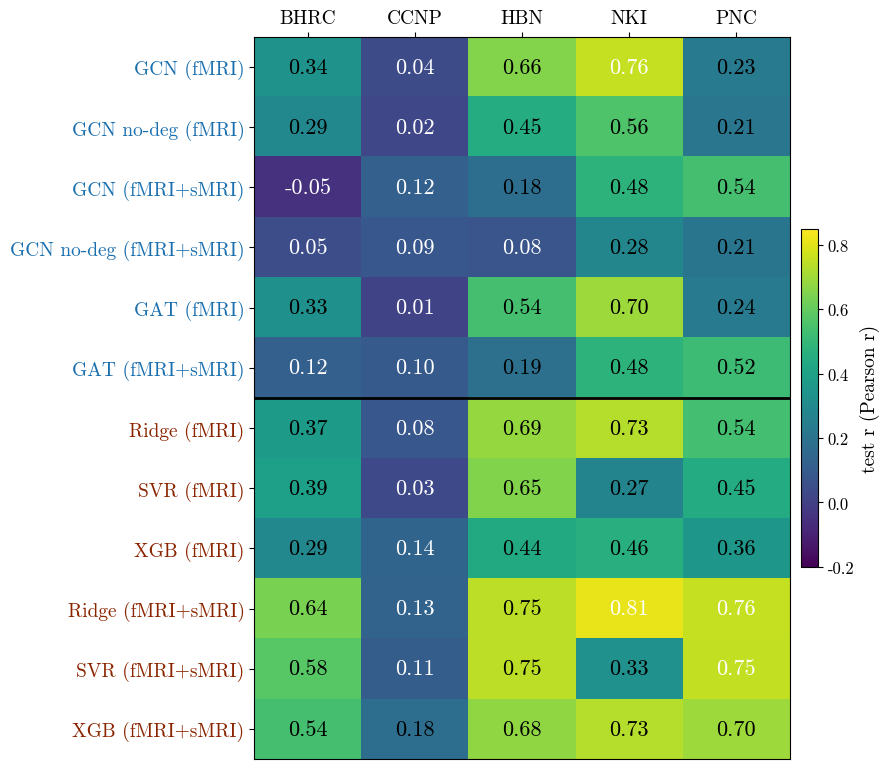

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import re as _re

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["cmr10", "STIXGeneral", "DejaVu Serif"]
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["axes.unicode_minus"] = False   # silences the cmr10 minus-sign warning

# ── Build data ────────────────────────────────────────────────────────────────
# GNN rows: mean test_r of top-5 trials (selected by best_state_val_loss) per split
# Baseline rows: test_r of single best config selected by val_r per split

def _arch_group_test(row):
    m = _re.search(r'_(gcn|gat)_(fmri|multi)', row["trial_id"])
    if m is None: return "unknown"
    arch = m.group(1).upper()
    mod  = "fMRI&sMRI" if m.group(2) == "multi" else "fMRI"
    is_nodeg = any(el.startswith("nodeg") for el in row["trial_id"].split("_"))
    return f"{arch}_{mod}" + ("_nodeg" if is_nodeg and arch != "GAT" else "")

split_labels = {s: f"{s.replace('LOO_','')}" for s in LOO_SPLITS}

hm_rows = []

for group in GROUPS:
    row = {"label": group, "kind": "GNN"}
    for split in LOO_SPLITS:
        res_csv  = os.path.join(DIR, split, "test_results.csv")
        loot_csv = os.path.join(DIR, split, "results_table.csv")
        if not os.path.exists(res_csv):
            row[split] = np.nan; continue
        test_df = pd.read_csv(res_csv)
        loo_df  = pd.read_csv(loot_csv)
        loo_df["arch"] = loo_df.apply(_arch_group_test, axis=1)
        merged = loo_df.merge(test_df, on="trial_id", how="inner")
        sub = merged[merged["arch"] == group].nsmallest(5, "best_state_val_loss")
        row[split] = round(sub["test_r"].mean(), 3) if not sub.empty else np.nan
    hm_rows.append(row)

# Collect all baseline labels first so order is consistent
bl_labels_seen = []
bl_data_by_label = {}
for split in LOO_SPLITS:
    csv_path = os.path.join(DIR, "BaselineExperiments", split, "results_table.csv")
    if not os.path.exists(csv_path): continue
    bl_df = pd.read_csv(csv_path)
    bl_df = bl_df[bl_df["r_test"].notna()].copy()
    bl_df["model"]    = bl_df["name"].str.split(".").str[0]
    bl_df["modality"] = bl_df["name"].apply(lambda x: "fMRI&sMRI" if "fMRI&sMRI" in x else "fMRI")
    best = bl_df.loc[bl_df.groupby(["model","modality"])["r_val"].idxmax()]
    for _, r in best.sort_values(["modality","model"]).iterrows():
        lbl = f"{r['model']} ({r['modality']})".replace("&","&")
        if lbl not in bl_data_by_label:
            bl_data_by_label[lbl] = {"label": lbl, "kind": "Baseline"}
            bl_labels_seen.append(lbl)
        bl_data_by_label[lbl][split] = round(r["r_test"], 3)

hm_rows.extend(bl_data_by_label[lbl] for lbl in bl_labels_seen)

labels = [r["label"] for r in hm_rows]
kinds  = [r["kind"]  for r in hm_rows]
matrix = np.array([[r.get(s, np.nan) for s in LOO_SPLITS] for r in hm_rows])
col_labels = [split_labels[s] for s in LOO_SPLITS]

# ── Plot ──────────────────────────────────────────────────────────────────────
n_gnn = sum(1 for k in kinds if k == "GNN")
fig, ax = plt.subplots(figsize=(9, 0.55 * len(labels) + 1.2))

im = ax.imshow(matrix, aspect="auto", cmap="viridis", vmin=-0.2, vmax=0.85)

# Annotate cells
for i in range(len(labels)):
    for j in range(len(LOO_SPLITS)):
        val = matrix[i, j]
        if np.isnan(val):
            txt = "–"
            color = "grey"
        else:
            txt = f"{val:.2f}"
            color = "black" if 0.15 < val < 0.75 else "white"
        ax.text(j, i, txt, ha="center", va="center", fontsize=16,
                color=color, fontweight="bold")

# Separator line between GNN and Baseline sections
ax.axhline(n_gnn - 0.5, color="black", linewidth=2)

ax.set_xticks(range(len(LOO_SPLITS)))
ax.set_xticklabels(col_labels, fontsize=14, fontweight="bold")
ax.set_yticks(range(len(labels)))
def _pretty(s):
    # Baselines already arrive as "Ridge (fMRI&sMRI)" — just fix the ampersand
    if "(" in s:
        return s.replace("&", "+")
    # GNNs arrive as "GCN_fMRI", "GCN_fMRI&sMRI", "GCN_fMRI&sMRI_nodeg", "GAT_fMRI"
    nodeg = s.endswith("_nodeg")
    s = s.replace("_nodeg", "")
    arch, mod = s.split("_", 1)          # "GCN", "fMRI&sMRI"
    mod = mod.replace("&", "+")          # "fMRI+sMRI"
    suffix = " no-deg" if nodeg else ""
    return f"{arch}{suffix} ({mod})"

ax.set_yticklabels([_pretty(l) for l in labels], fontsize=14)
ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()

# Row colour bands
for i, kind in enumerate(kinds):
    ax.get_yticklabels()[i].set_color("#1a6faf" if kind == "GNN" else "#8b2500")

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.ax.tick_params(labelsize=12)
cbar.set_label("test r (Pearson r)", fontsize=14)# ax.set_title("test r per LOO split\n"
#              "GNN: mean of top-5 trials (selected by val loss) | "
#              "Baseline: best single config (selected by val r)",
#              fontsize=9, pad=14)
plt.tight_layout()
plt.savefig(os.path.join(DIR, FIGURES_DIR, "test_r_heatmap.pdf"),
            bbox_inches="tight")


plt.show()



In [ ]:
# ── Same data as the heatmap above, plain table form (no color) ────────────────
heatmap_table_df = pd.DataFrame(matrix, index=labels, columns=col_labels)
heatmap_table_df.insert(0, "Model", kinds)
print("test_r per LOO split (same data as heatmap)")
display(heatmap_table_df)

test_r per LOO split (same data as heatmap)


,Model,BHRC,CCNP,HBN,NKI,PNC
GCN_fMRI,GNN,0.340,0.041,0.655,0.759,0.228
GCN_fMRI_nodeg,GNN,0.289,0.023,0.451,0.560,0.213
GCN_fMRI&sMRI,GNN,-0.050,0.122,0.179,0.477,0.541
GCN_fMRI&sMRI_nodeg,GNN,0.050,0.085,0.076,0.282,0.208
GAT_fMRI,GNN,0.327,0.014,0.539,0.698,0.237
GAT_fMRI&sMRI,GNN,0.121,0.099,0.186,0.477,0.521
Ridge (fMRI),Baseline,0.374,0.084,0.685,0.733,0.535
SVR (fMRI),Baseline,0.394,0.031,0.652,0.273,0.445
XGB (fMRI),Baseline,0.291,0.138,0.437,0.461,0.356
Ridge (fMRI&sMRI),Baseline,0.640,0.133,0.747,0.815,0.757


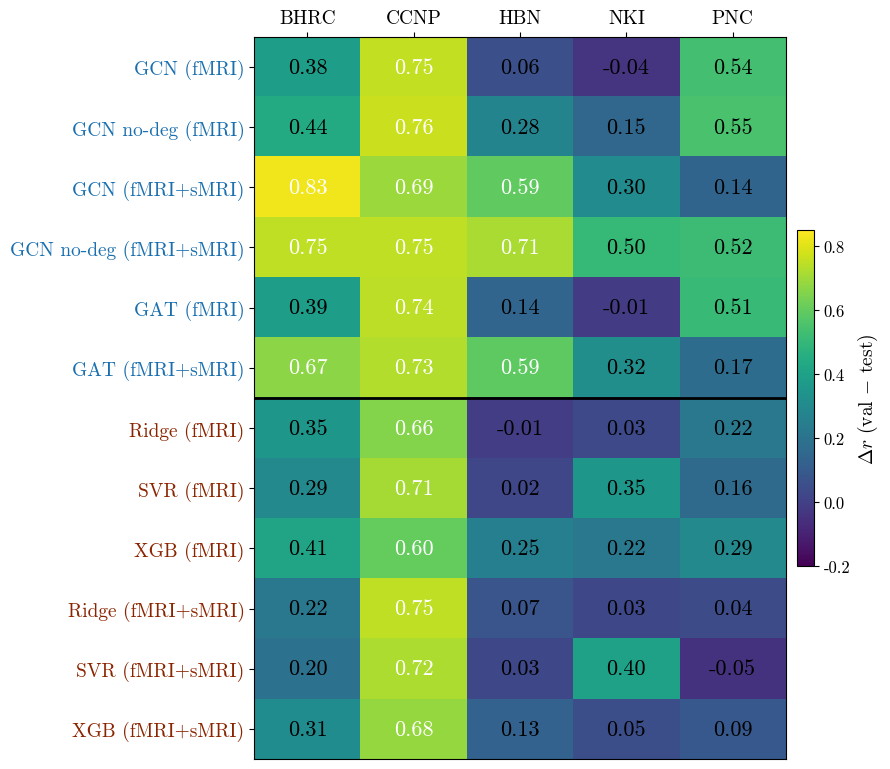

In [ ]:
# ── Δr heatmap (val_r − test_r): same layout as test_r heatmap ───────────────
import matplotlib.pyplot as plt
import numpy as np
import re as _re

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["cmr10", "STIXGeneral", "DejaVu Serif"]
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["axes.unicode_minus"] = False

# ── GNN rows: mean(val_r − test_r) over top-5 per split ─────────────────────
dr_rows = []

for group in GROUPS:
    row = {"label": group, "kind": "GNN"}
    for split in LOO_SPLITS:
        res_csv  = os.path.join(DIR, split, "test_results.csv")
        loot_csv = os.path.join(DIR, split, "results_table.csv")
        if not os.path.exists(res_csv):
            row[split] = np.nan; continue
        test_df = pd.read_csv(res_csv)
        loo_df  = pd.read_csv(loot_csv)
        loo_df["arch"] = loo_df.apply(_arch_group_test, axis=1)
        merged = loo_df.merge(test_df, on="trial_id", how="inner")
        sub = merged[merged["arch"] == group].nsmallest(5, "best_state_val_loss")
        row[split] = round((sub["best_val_r"] - sub["test_r"]).mean(), 3) if not sub.empty else np.nan
    dr_rows.append(row)

# ── Baseline rows: val_r − test_r for best config per split ──────────────────
bl_labels_seen_dr = []
bl_data_by_label_dr = {}
for split in LOO_SPLITS:
    csv_path = os.path.join(DIR, "BaselineExperiments", split, "results_table.csv")
    if not os.path.exists(csv_path): continue
    bl_df = pd.read_csv(csv_path)
    bl_df = bl_df[bl_df["r_test"].notna()].copy()
    bl_df["model"]    = bl_df["name"].str.split(".").str[0]
    bl_df["modality"] = bl_df["name"].apply(lambda x: "fMRI&sMRI" if "fMRI&sMRI" in x else "fMRI")
    best = bl_df.loc[bl_df.groupby(["model", "modality"])["r_val"].idxmax()]
    for _, r in best.sort_values(["modality", "model"]).iterrows():
        lbl = f"{r['model']} ({r['modality']})".replace("&", "&")
        if lbl not in bl_data_by_label_dr:
            bl_data_by_label_dr[lbl] = {"label": lbl, "kind": "Baseline"}
            bl_labels_seen_dr.append(lbl)
        bl_data_by_label_dr[lbl][split] = round(r["r_val"] - r["r_test"], 3)

dr_rows.extend(bl_data_by_label_dr[lbl] for lbl in bl_labels_seen_dr)

labels_dr = [r["label"] for r in dr_rows]
kinds_dr  = [r["kind"]  for r in dr_rows]
matrix_dr = np.array([[r.get(s, np.nan) for s in LOO_SPLITS] for r in dr_rows])
col_labels_dr = [s.replace("LOO_", "") for s in LOO_SPLITS]

# ── Plot ──────────────────────────────────────────────────────────────────────
n_gnn_dr = sum(1 for k in kinds_dr if k == "GNN")
fig, ax = plt.subplots(figsize=(9, 0.55 * len(labels_dr) + 1.2))

im = ax.imshow(matrix_dr, aspect="auto", cmap="viridis", vmin=-0.2, vmax=0.85)

for i in range(len(labels_dr)):
    for j in range(len(LOO_SPLITS)):
        val = matrix_dr[i, j]
        if np.isnan(val):
            txt, color = "–", "grey"
        else:
            txt   = f"{val:.2f}"
            color = "black" if val < 0.55 else "white"
        ax.text(j, i, txt, ha="center", va="center", fontsize=16,
                color=color, fontweight="bold")

ax.axhline(n_gnn_dr - 0.5, color="black", linewidth=2)

ax.set_xticks(range(len(LOO_SPLITS)))
ax.set_xticklabels(col_labels_dr, fontsize=14, fontweight="bold")
ax.set_yticks(range(len(labels_dr)))
ax.set_yticklabels([_pretty(l) for l in labels_dr], fontsize=14)
ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()

for i, kind in enumerate(kinds_dr):
    ax.get_yticklabels()[i].set_color("#1a6faf" if kind == "GNN" else "#8b2500")

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.ax.tick_params(labelsize=12)
cbar.set_label(r"$\Delta r$ (val $-$ test)", fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(DIR, FIGURES_DIR, "delta_r_heatmap.pdf"), bbox_inches="tight")
plt.show()


In [20]:
# ── Same data as the heatmap above, plain table form (no color) ────────────────
heatmap_table_df = pd.DataFrame(matrix_dr, index=labels, columns=col_labels)
heatmap_table_df.insert(0, "Model", kinds)
print("test_r per LOO split (same data as heatmap)")
display(heatmap_table_df)

test_r per LOO split (same data as heatmap)


,Model,BHRC,CCNP,HBN,NKI,PNC
GCN_fMRI,GNN,0.384,0.752,0.055,-0.041,0.536
GCN_fMRI_nodeg,GNN,0.443,0.764,0.275,0.146,0.549
GCN_fMRI&sMRI,GNN,0.827,0.693,0.592,0.305,0.137
GCN_fMRI&sMRI_nodeg,GNN,0.748,0.751,0.715,0.502,0.518
GAT_fMRI,GNN,0.385,0.745,0.141,-0.013,0.508
GAT_fMRI&sMRI,GNN,0.669,0.729,0.589,0.317,0.172
Ridge (fMRI),Baseline,0.354,0.655,-0.008,0.033,0.220
SVR (fMRI),Baseline,0.294,0.707,0.022,0.354,0.163
XGB (fMRI),Baseline,0.413,0.603,0.253,0.222,0.293
Ridge (fMRI&sMRI),Baseline,0.219,0.751,0.075,0.026,0.043


In [22]:
# ── Overall ranking by mean test_r excluding CCNP ────────────────────────────
# GNN: mean test_r of top-5 trials averaged over BHRC, HBN, NKI, PNC
# Baseline: test_r of best-by-val_r config averaged over BHRC, HBN, NKI, PNC

_excl = [s for s in LOO_SPLITS if s != "LOO_CCNP"]

rank_rows = []
for r in hm_rows:
    vals = [r.get(s, float("nan")) for s in _excl]
    vals_clean = [v for v in vals if not pd.isna(v)]
    mean_excl = round(sum(vals_clean) / len(vals_clean), 3) if vals_clean else float("nan")
    rank_rows.append({
        "Model":                  r["label"],
        "Type":                   r["kind"],
        "Mean test_r (excl CCNP)": mean_excl,
        **{s: r.get(s, float("nan")) for s in LOO_SPLITS},
    })

rank_df = (pd.DataFrame(rank_rows)
             .set_index("Model")
             .sort_values("Mean test_r (excl CCNP)", ascending=False))
print("Overall ranking by mean test_r (BHRC + HBN + NKI + PNC, CCNP excluded)")
print("GNN score = mean of top-5 trials  |  Baseline score = best single config selected by val_r")
display(rank_df)


Overall ranking by mean test_r (BHRC + HBN + NKI + PNC, CCNP excluded)
GNN score = mean of top-5 trials  |  Baseline score = best single config selected by val_r


,Type,Mean test_r (excl CCNP),LOO_BHRC,LOO_CCNP,LOO_HBN,LOO_NKI,LOO_PNC
Model,,,,,,,
Ridge (fMRI&sMRI),Baseline,0.740,0.640,0.133,0.747,0.815,0.757
XGB (fMRI&sMRI),Baseline,0.661,0.541,0.180,0.675,0.732,0.698
SVR (fMRI&sMRI),Baseline,0.603,0.579,0.110,0.746,0.333,0.753
Ridge (fMRI),Baseline,0.582,0.374,0.084,0.685,0.733,0.535
GCN_fMRI,GNN,0.496,0.340,0.041,0.655,0.759,0.228
GAT_fMRI,GNN,0.450,0.327,0.014,0.539,0.698,0.237
SVR (fMRI),Baseline,0.441,0.394,0.031,0.652,0.273,0.445
XGB (fMRI),Baseline,0.386,0.291,0.138,0.437,0.461,0.356
GCN_fMRI_nodeg,GNN,0.378,0.289,0.023,0.451,0.560,0.213


In [27]:
# ── Summary table: mean across BHRC, HBN, NKI, PNC (CCNP excluded) ──────────

_splits_excl = [s for s in LOO_SPLITS if s != "LOO_CCNP"]

summary_rows = []

# GNN rows: collect all 20 values (top-5 × 4 splits), mean ± std over 20
for group in GROUPS:
    val_rs, val_maes, test_rs, test_maes, delta_rs, delta_maes = [], [], [], [], [], []
    for split in _splits_excl:
        df = top_k[split][group].dropna(subset=["test_r", "test_mae"])
        val_rs.extend(df["best_val_r"].tolist())
        val_maes.extend(df["best_val_mae"].tolist())
        test_rs.extend(df["test_r"].tolist())
        test_maes.extend(df["test_mae"].tolist())
        delta_rs.extend((df["best_val_r"] - df["test_r"]).tolist())
        delta_maes.extend((df["test_mae"] - df["best_val_mae"]).tolist())

    def ms(a): return np.mean(a), np.std(a)
    mvr,   svr   = ms(val_rs)
    mvmae, svmae = ms(val_maes)
    mtr,   str_  = ms(test_rs)
    mtmae, stmae = ms(test_maes)
    mdr,   sdr   = ms(delta_rs)
    mdmae, sdmae = ms(delta_maes)

    summary_rows.append({
        "Kind":     "GNN",
        "Model":    group,
        "Val r":    f"{mvr:.3f} ± {svr:.3f}",
        "Val MAE":  f"{mvmae:.2f} ± {svmae:.2f}",
        "Test r":   f"{mtr:.3f} ± {str_:.3f}",
        "Test MAE": f"{mtmae:.2f} ± {stmae:.2f}",
        "Δr":       f"{mdr:.3f} ± {sdr:.3f}",
        "ΔMAE":     f"{mdmae:.2f} ± {sdmae:.2f}",
        "_sort":    mtr,
    })

# Baseline rows: best-by-val_r config per split → mean ± std over 4 splits
bl_accum = {}
for split in _splits_excl:
    for label, v in _load_best_baselines(split).items():
        if label not in bl_accum:
            bl_accum[label] = {"val_r": [], "val_mae": [], "test_r": [], "test_mae": [],
                               "delta_r": [], "delta_mae": []}
        bl_accum[label]["val_r"].append(v["val_r"])
        bl_accum[label]["val_mae"].append(v["val_mae"])
        bl_accum[label]["test_r"].append(v["test_r"])
        bl_accum[label]["test_mae"].append(v["test_mae"])
        bl_accum[label]["delta_r"].append(v["val_r"] - v["test_r"])
        bl_accum[label]["delta_mae"].append(v["test_mae"] - v["val_mae"])

for label, vals in bl_accum.items():
    mvr,   svr   = ms(vals["val_r"])
    mvmae, svmae = ms(vals["val_mae"])
    mtr,   str_  = ms(vals["test_r"])
    mtmae, stmae = ms(vals["test_mae"])
    mdr,   sdr   = ms(vals["delta_r"])
    mdmae, sdmae = ms(vals["delta_mae"])
    summary_rows.append({
        "Kind":     "Baseline",
        "Model":    label,
        "Val r":    f"{mvr:.3f} ± {svr:.3f}",
        "Val MAE":  f"{mvmae:.2f} ± {svmae:.2f}",
        "Test r":   f"{mtr:.3f} ± {str_:.3f}",
        "Test MAE": f"{mtmae:.2f} ± {stmae:.2f}",
        "Δr":       f"{mdr:.3f} ± {sdr:.3f}",
        "ΔMAE":     f"{mdmae:.2f} ± {sdmae:.2f}",
        "_sort":    mtr,
    })

summary_df = (pd.DataFrame(summary_rows)
                .sort_values("_sort", ascending=False)
                .drop(columns="_sort")
                .set_index(["Kind", "Model"]))

print("Summary: mean across BHRC + HBN + NKI + PNC (CCNP excluded)")
print("GNN = mean ± std over 20 trials (top-5 × 4 splits) | Baseline = mean ± std over 4 splits (best config by val_r)")
display(summary_df)


Summary: mean across BHRC + HBN + NKI + PNC (CCNP excluded)
GNN = mean ± std over 20 trials (top-5 × 4 splits) | Baseline = mean ± std over 4 splits (best config by val_r)


Val r      Val MAE         Test r  \
Kind     Model                                                            
Baseline Ridge (fMRI&sMRI)    0.831 ± 0.022  1.64 ± 0.07  0.740 ± 0.063   
         XGB (fMRI&sMRI)      0.807 ± 0.027  1.77 ± 0.10  0.661 ± 0.072   
         SVR (fMRI&sMRI)      0.747 ± 0.028  2.00 ± 0.07  0.603 ± 0.171   
         Ridge (fMRI)         0.732 ± 0.034  2.10 ± 0.16  0.582 ± 0.140   
GNN      GCN_fMRI             0.729 ± 0.023  2.03 ± 0.19  0.495 ± 0.227   
         GAT_fMRI             0.706 ± 0.026  2.11 ± 0.20  0.450 ± 0.189   
Baseline SVR (fMRI)           0.649 ± 0.033  2.36 ± 0.08  0.441 ± 0.137   
         XGB (fMRI)           0.681 ± 0.020  2.27 ± 0.08  0.386 ± 0.067   
GNN      GCN_fMRI_nodeg       0.732 ± 0.021  2.03 ± 0.18  0.378 ± 0.190   
         GAT_fMRI&sMRI        0.763 ± 0.041  1.90 ± 0.06  0.326 ± 0.190   
         GCN_fMRI&sMRI        0.752 ± 0.043  1.94 ± 0.04  0.287 ± 0.249   
         GCN_fMRI&sMRI_nodeg  0.775 ± 0.029  1.89 ± 0.04  0.154 ± 0.166   

                                 Test MAE             Δr         ΔMAE  
Kind     Model                                                         
Baseline Ridge (fMRI&sMRI)    2.18 ± 0.37  0.091 ± 0.076  0.54 ± 0.41  
         XGB (fMRI&sMRI)      2.92 ± 0.65  0.145 ± 0.099  1.16 ± 0.72  
         SVR (fMRI&sMRI)      3.07 ± 1.02  0.144 ± 0.172  1.07 ± 1.00  
         Ridge (fMRI)         5.18 ± 2.12  0.150 ± 0.146  3.08 ± 2.21  
GNN      GCN_fMRI             3.17 ± 1.29  0.234 ± 0.243  1.14 ± 1.45  
         GAT_fMRI             3.57 ± 1.25  0.255 ± 0.212  1.46 ± 1.37  
Baseline SVR (fMRI)           3.54 ± 0.80  0.208 ± 0.128  1.18 ± 0.86  
         XGB (fMRI)           3.33 ± 0.93  0.295 ± 0.072  1.06 ± 0.99  
GNN      GCN_fMRI_nodeg       4.11 ± 1.72  0.353 ± 0.204  2.08 ± 1.76  
         GAT_fMRI&sMRI        3.73 ± 1.28  0.437 ± 0.214  1.83 ± 1.29  
         GCN_fMRI&sMRI        3.24 ± 1.03  0.465 ± 0.276  1.30 ± 1.05  
         GCN_fMRI&sMRI_nodeg  3.48 ± 1.19  0.621 ± 0.178  1.59 ± 1.18

Key observations:

- CCNP is basically failing as a test set — test_r near 0 or negative, R² very negative. Almost certainly a distribution shift issue (age range, scanner, protocol).
- HBN and NKI generalize best — test_r ~0.6–0.7, positive R². These are likely the most similar to the training distribution.
- Huge val→test gap everywhere — val_r ~0.7–0.8 but test_r drops dramatically. This is expected for OOD but worth quantifying explicitly.
- Negative R² on several splits means the model is worse than predicting the mean age. That's a serious OOD failure mode worth highlighting.

**Baseline comparison:**

- Ridge is the strongest baseline on 4/5 splits; SVR is competitive on fMRI-only but degrades more on fMRI&sMRI for some splits; XGB is consistently the weakest of the three.
- For baselines, adding sMRI (fMRI&sMRI) consistently raises both val and test performance, and in most cases *reduces* the OOD gap (Δr smaller for fMRI&sMRI vs fMRI) — most clearly for Ridge and XGB, less so for SVR.
- CCNP is the exception: all three baselines show a *larger* gap with fMRI&sMRI because val performance jumps substantially while test_r barely moves (~0.08→0.13). The sMRI features add in-distribution signal that does not transfer to CCNP.
- **The critical contrast with GNNs:** sMRI features help linear baselines generalize OOD, but adding sMRI to the GNN *hurts* OOD performance (GCN/GAT fMRI&sMRI test_r collapses on BHRC and HBN). Ridge fMRI&sMRI is the best overall model on 4/5 splits. This asymmetry points to a structural failure in the GNN’s multimodal fusion — not a problem with the sMRI features themselves.
- GCN_fMRI is competitive with Ridge fMRI on HBN (0.655 vs 0.685) and outperforms it on NKI (0.759 vs 0.733), suggesting the graph-based fMRI representation is meaningful. The failure is specific to multimodal integration under distribution shift.

**Additional observations:**

- **GCN_fMRI is the most reliable GNN** — best on 3/5 splits (BHRC, HBN, NKI), mean test_r = 0.471 excl. CCNP. Degree normalization is not optional: every _nodeg variant is worse.
- **PNC is the flip case** — GCN/GAT fMRI&sMRI (0.541 / 0.521) beats GCN/GAT fMRI (0.228 / 0.237) on PNC, the *only* split where multimodal GNN outperforms fMRI-only. The pattern is reversed on every other split.
- **nodeg + NKI = calibration failure** — GCN_fMRI_nodeg achieves test_r = 0.560 but test_MAE = 6.00 years. Predictions are correlated with age but severely biased in scale. Without the degree normalization the amplified contribution of high degree nodes resulted in a calibration failure.
- **Overall ranking excl. CCNP (mean test_r over BHRC, HBN, NKI, PNC):** Ridge fMRI&sMRI (0.740) > XGB fMRI&sMRI (0.661) > SVR fMRI&sMRI (0.603) > Ridge fMRI (0.582) > GCN_fMRI (0.496) > GAT_fMRI (0.450) > rest of GNNs. GNN score = mean of top-5 trials; baseline score = best single config selected by val_r.
- **CCNP fails universally** — even the best baseline (XGB fMRI&sMRI) reaches only test_r = 0.181. This is a dataset-level issue (likely demographic/scanner mismatch), not a modelling failure.